In [1]:
import numpy as np
from netCDF4 import Dataset
import pandas as pd
import datetime as dt
import fiona
import xarray

# find indices of grid cell containing x, y
def get_nearest_xy(x, y, x_array, y_array):
   """
     Search for nearest grid cell in an array of grid cells and return the index.
     np.argmin returns the indices of minium value along an axis.
     Subtract dd from all values in dd_array, take absolute value and find index of minimum.
    """
   x_idx = (np.abs(x_array - x)).argmin()
   y_idx = (np.abs(y_array - y)).argmin()
   return x_idx, y_idx
##

region = 'Mexico'
locs = ['Guadalajara', 'León', 'Mérida', 'Mexico City', 'Monterrey', 'Oaxaca']
home_dir = '<home_dir>'
bucket = '<gcloud_bucket>'

##
# specify if selecting data based on polygon or single latlon point
# polygon selection results in selecting a rectangle of data based on extent of polygon
poly_or_latlon = 'latlon'

# path to polygon shapefiles
#polygon_path = f'{home_dir}/{bucket}/<poly_path>'
#polygons = [f'{polygon_path}/{loc.replace(" ", "")}.shp' for loc in locs]

# latlon tuples for single points
latlons = [(20.67, -103.36), (21.12, -101.68), (20.97, -89.61), (19.44, -99.13), (25.70, -100.31), (17.07, -96.72)]
##

ssp = 'ssp585'
variable = 'tasmax'
variable_long = 'maximum_temperature'
units = 'C'
days_since = dt.datetime(1850, 1, 1)  # specific to time in nc file

season = 'AMJJAS'
months2include = {
#    'January': 1,
#    'February': 2,
#    'March': 3,
    'April': 4,
    'May': 5,
    'June':6,
    'July': 7,
    'August': 8,
    'September': 9,
#    'October': 10,
#    'November': 11,
#   'December': 12
}

percentile = 0.95  # decimal

data_paths = [f'{home_dir}/{bucket}/Daymet/{loc.replace(" ", "")}/{variable}' for loc in locs]
save_path = f'{home_dir}/{bucket}/Wellington/{region}'

with open(f'{home_dir}/modelNames.txt') as f:
    models = [line.strip() for line in f]
    
yrs_base = np.arange(1971, 2000 + 1)
yrs_fut = np.arange(2021, 2050 + 1)
yrs_fut2 = []  # np.arange(2070, 2090 + 1)

num_periods = 2  # number of time periods for analysis
if len(yrs_fut2) > 0:
    num_periods = 3
    
base_list = np.array([])
fut_list = np.array([])
fut2_list = np.array([])

# assemble df column names based on desired years
col1 = 'location'
col2 = '%s-%s' % (yrs_base[0], yrs_base[-1])
col3 = '%s-%s' % (yrs_fut[0], yrs_fut[-1])
if len(yrs_fut2) > 0:
    col4 = '%s-%s' % (yrs_fut2[0], yrs_fut2[-1])
    

In [ ]:
# subset data by time and month
def subsetTime(da, months):
    da = da.sel(time=da.time.dt.month.isin(months))
    return da

# remove leap days so each time period has the same number of days
def removeLeapDays(da):
    mask = np.logical_and(da.time.dt.is_leap_year, da.time.dt.dayofyear==60)
    da_noleapdays = da.where(~mask, drop=True)
    return da_noleapdays

# read in data and build df based on years
df1 = pd.DataFrame(columns=[col1, col2])
df2 = pd.DataFrame(columns=[col1, col3])
if len(yrs_fut2) > 0:
    df3 = pd.DataFrame(columns=[col1, col4])

for loc in enumerate(locs):
    if poly_or_latlon == 'poly':
        # load location's polygon and get extent
        poly = fiona.open(polygons[loc[0]])
        lat1, lat2, lon1, lon2 = poly.bounds[1], poly.bounds[3], poly.bounds[0], poly.bounds[2]
        print(loc[1], lat1, lat2, lon1, lon2)
    elif poly_or_latlon == 'latlon':
        loc_lat, loc_lon = latlons[loc[0]][0], latlons[loc[0]][1]       
        print(loc[1], lat, lon)
    
    for m in models:
        print(f'  {m}')
        df_loc = pd.DataFrame(columns=[col1])  # temporary dataframe for location and model

        for i in np.arange(0, num_periods): # loop through time periods (base, fut, and fut2)
            if i == 0:  # base time period
                print('     Loading data for base time period')
                data = xarray.open_dataset(\
                       f'{data_paths[loc[0]]}/{loc[1].replace(" ", "")}_{variable}_{m}_{ssp}_{col2}_ds_bil_daymet_then_ba.nc') 
            elif i == 1:  # future time period
                print('     Loading data for first future time period')
                data = xarray.open_dataset(\
                       f'{data_paths[loc[0]]}/{loc[1].replace(" ", "")}_{variable}_{m}_{ssp}_{col3}_ds_bil_daymet_then_ba.nc')
            elif (i == 2) and (len(yrs_fut2) > 0):  # (possible) second future time period
                print('     Loading data for second future time period')
                data = xarray.open_dataset(\
                       f'{data_paths[loc[0]]}/{loc[1].replace(" ", "")}_{variable}_{m}_{ssp}_{col4}_ds_bil_daymet_then_ba.nc')
            else: 
                print('ERROR: Exactly two or three time periods must be specified!')

            data = subsetTime(data, list(months2include.values()))
            data = removeLeapDays(data)

            if poly_or_latlon == 'poly':
                # select data within upper and lower bounds of polygon extent (results in a rectangle)
                data = data.where((data.lat >= lat1) & (data.lat <= lat2) &\
                                  (data.lon >= lon1) & (data.lon <= lon2))
            elif poly_or_latlon == 'latlon':
                # select data closest to specified latlon
                data = data.sel(lon=loc_lon, lat=loc_lat, method='nearest')
            else:
                print('ERROR: User must specify "poly" or "latlon" for method of spatially subsetting data')
                
            data = data[variable].to_numpy()
            data = data[np.isfinite(data)]  # drop nans
        
            if i == 0:
                df_loc[col2] = data
                df_loc[col1] = loc[1]
                df1 = pd.concat([df1, df_loc])
            elif i == 1:
                df_loc[col3] = data
                df_loc[col1] = loc[1]
                df2 = pd.concat([df2, df_loc])
            elif (i == 2) and (len(yrs_fut2) > 0):
                df_loc[col4] = data
                df_loc[col1] = loc[1]
                df3 = pd.concat([df3, df_loc])
            else:
                print('ERROR: Exactly two or three time periods must be specified!')
        
            data.close()
            
df = df1.combine_first(df2)
if len(yrs_fut2) > 0:
    df = df.combine_first(df3)

df.reset_index(drop=True)

location = df[col1]  # 'combine_first' moved location to end. This sequence brings it back to the first column
df = df.drop(columns=col1)
df.insert(loc=0, column=col1, value=location)

# save data
df.to_csv(f'{save_path}/{region.replace(' ' , '_')}_cities_{variable}_distribution_data_{season}_daymet.csv', index=False)

df        

In [4]:
# load data
df = pd.read_csv(f'{save_path}/{region.replace(" " , "_")}_cities_{variable}_distribution_data_{season}_daymet.csv', header=0)

df.iloc[:, 1:] = df.iloc[:, 1:] - 273.15  # K to C

if units == 'F':
    df.iloc[:, 1:] = df.iloc[:, 1:] * 1.8 + 32  # C to F
    
df

,location,1971-2000,2021-2050
0,Guadalajara,29.11730,32.56735
1,Guadalajara,30.33303,31.26116
2,Guadalajara,31.75018,31.54020
3,Guadalajara,32.45754,33.05514
4,Guadalajara,31.71490,32.99944
...,...,...,...
559975,Oaxaca,25.04385,30.42635
559976,Oaxaca,24.59158,28.60067
559977,Oaxaca,25.80530,29.86337
559978,Oaxaca,27.44015,28.50723


In [5]:
# get 95th percentile values
percentiles = df.groupby(col1).quantile(q=percentile, interpolation='linear')
percentiles = np.round_(percentiles, decimals=1)

locs = sorted(locs)  # alphabetize locations to match percentile df order
percentiles

,1971-2000,2021-2050
location,,
Guadalajara,33.9,36.0
León,33.7,36.1
Mexico City,29.9,32.1
Monterrey,38.4,40.5
Mérida,37.5,38.9
Oaxaca,32.5,34.5


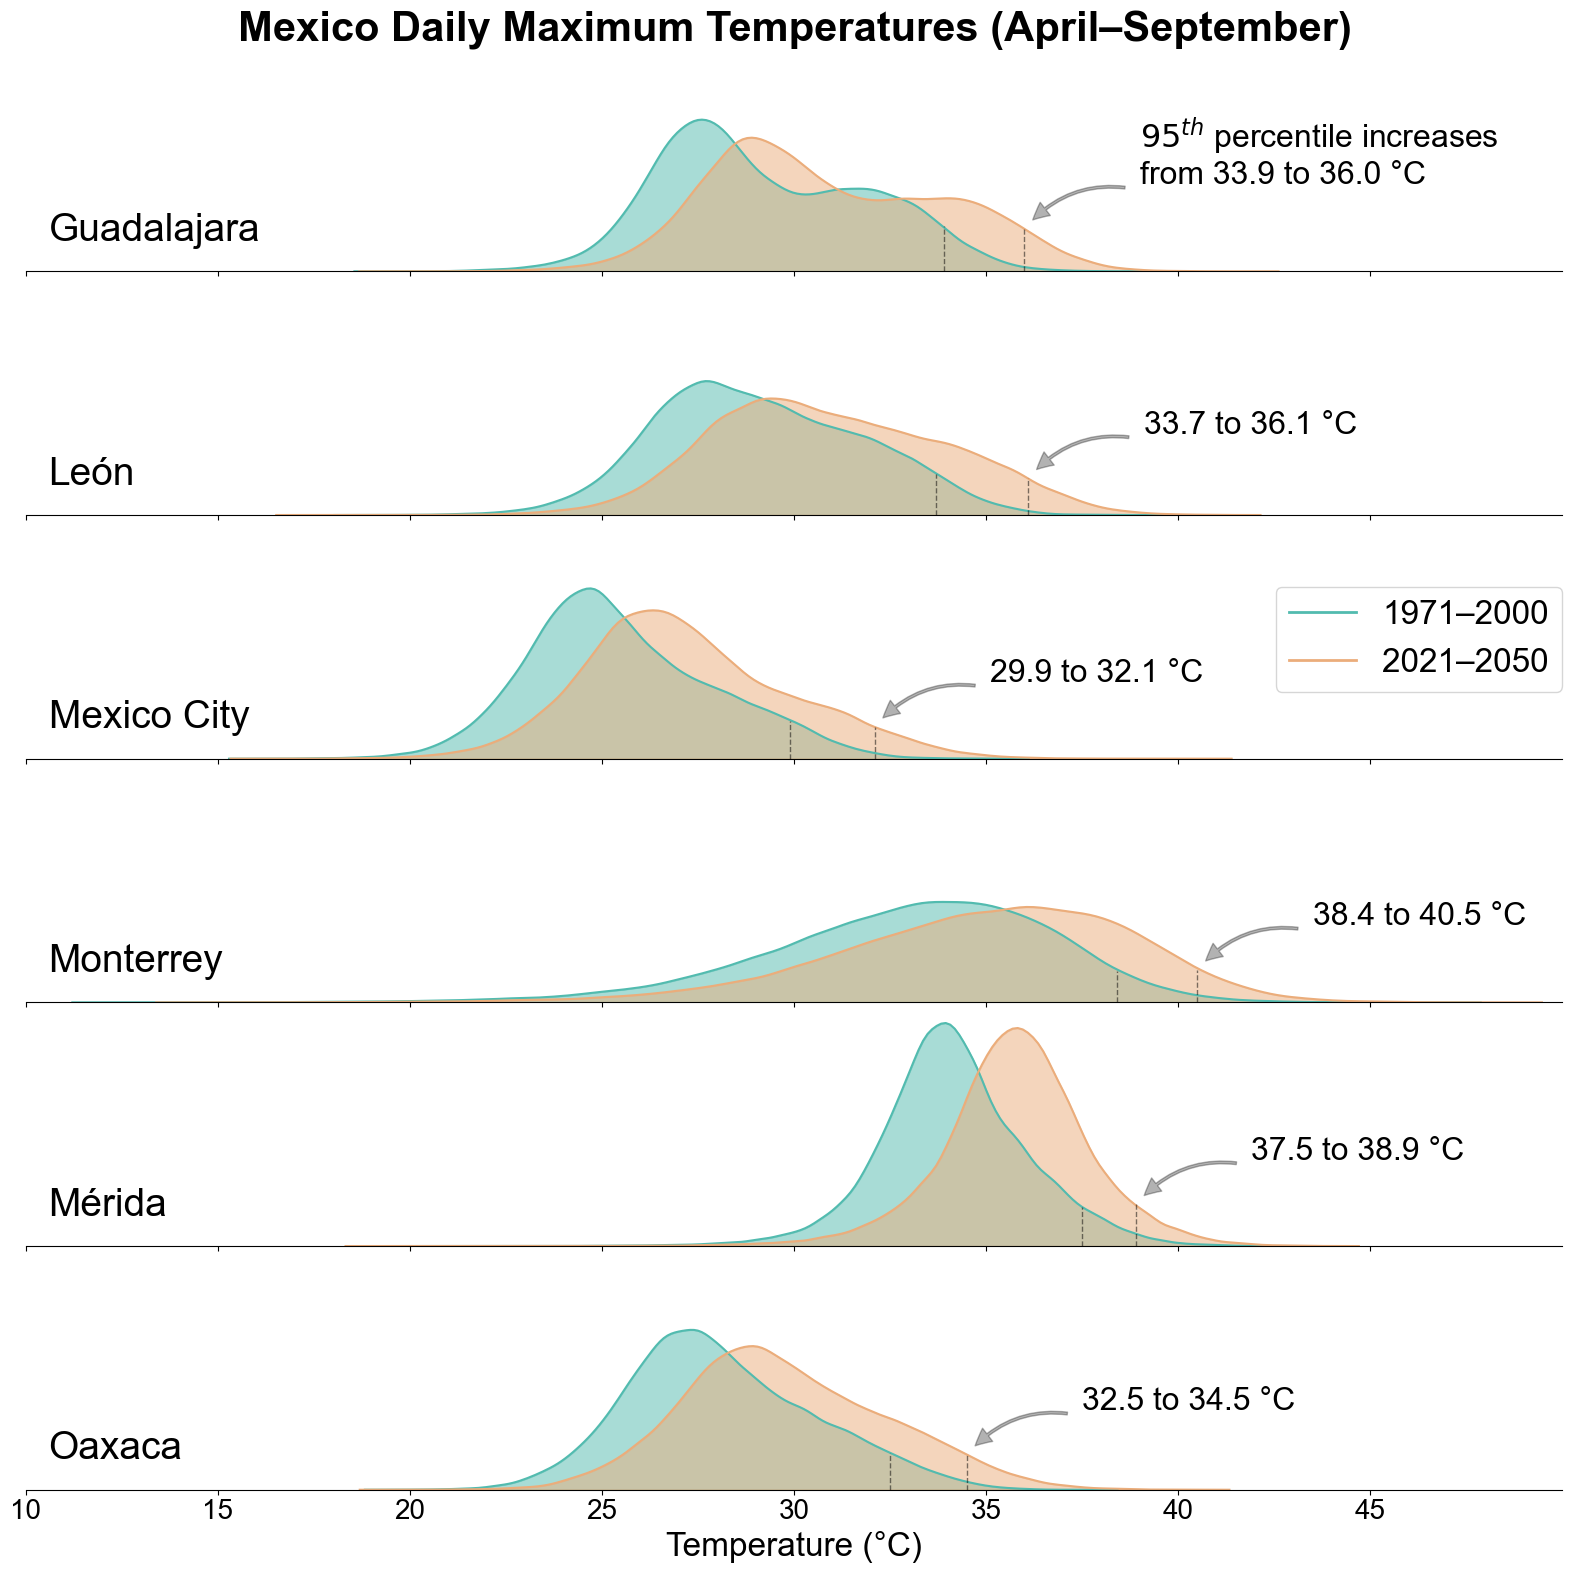

In [8]:
# plot distributions
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
plt.rcParams['font.family'] = ['Arial']

fontsize = 20

if len(yrs_fut2) > 0:
    colors = ['#52bbaf', '#e9c46a', '#ebad7b']
else:
    colors = ['#52bbaf', '#ebad7b']    

# group df by location
unique_locs = sorted(df[col1].unique())  # alphabetize locations
dfs_grouped_by_loc = [df.loc[df[col1] == ul] for ul in unique_locs]

height_of_fut_perc_line = []

# round xticks to nearest N, using min/max values of data as guiding limits
round_to = 5
xtick_min, xtick_max = np.around(np.min(df)[1] / 5, decimals=0) * 5, np.around(np.max(df)[-1] / 5, decimals=0) * 5

fig, axes = plt.subplots(len(unique_locs), 1, figsize=(16, 16))

# loop over grouped df to plot each location on separate axis
for loc_i in np.arange(len(dfs_grouped_by_loc)):

    for col_i in np.arange(0, len(df.columns) - 1):
        dis = sns.kdeplot(dfs_grouped_by_loc[loc_i].iloc[:, col_i + 1], color=colors[col_i], ax=axes[loc_i])
        dis_x = dis.lines[col_i].get_xydata()[:, 0]
        dis_y = dis.lines[col_i].get_xydata()[:, 1]
        dis.fill_between(dis_x, dis_y, color=colors[col_i], alpha=0.5)

        # find index where line is closest to percentile value
        percentile_idx = (np.abs(percentiles.iloc[loc_i][col_i] - dis_x)).argmin()

        if col_i == (len(df.columns) - 2): # save heights of last time period percentile line 
            height_of_fut_perc_line.append(dis_y[percentile_idx])
            
        # Nth percentile line
        axes[loc_i].vlines(x=percentiles.iloc[loc_i][col_i], ymin=0, ymax=dis_y[percentile_idx], colors='k', ls='--', lw=1, alpha=0.5)

    # location label
    axes[loc_i].text(0.015, 0.1, f'{locs[loc_i]}', verticalalignment='bottom', horizontalalignment='left', 
                     transform=axes[loc_i].transAxes, fontsize=fontsize + 8)         
    
    if loc_i > 0:  # skip annotating first subplot, that happens later
        axes[loc_i].annotate('%.1f to %.1f \u00B0%s' % 
                    (percentiles.iloc[loc_i][0], percentiles.iloc[loc_i][1], units), 
                    xy=(percentiles.iloc[loc_i][-1], height_of_fut_perc_line[loc_i]),
                    xytext=(percentiles.iloc[loc_i][-1] + 3,  # offset adjusts text horizontally
                            height_of_fut_perc_line[loc_i] + 0.05),  # offset adjusts text vertically
                    fontsize=fontsize + 3, 
                    arrowprops=dict(facecolor='black',
                                    shrink=0.1,
                                    alpha=0.3,
                                    width=2,
                                    connectionstyle='arc3,rad=0.3'))
                             
    axes[loc_i].set_xlim((xtick_min, xtick_max))
    axes[loc_i].set_ylim((0, 0.25))  # adjust height of subplots by altering second value
    axes[loc_i].set_xticks(np.arange(xtick_min, xtick_max, 5), fontsize=fontsize)
    axes[loc_i].set_yticks([])
    if loc_i != len(locs) -1:
        axes[loc_i].set_xticklabels('')
    axes[loc_i].set_xlabel('')
    axes[loc_i].set_ylabel('')
    axes[loc_i].spines['top'].set_visible(False)
    axes[loc_i].spines['right'].set_visible(False)
    axes[loc_i].spines['left'].set_visible(False)

# annotate first subplot
axes[0].annotate('$%d^{th}$ percentile increases\nfrom %.1f to %.1f \u00B0%s' % \
    (percentile*100, percentiles.iloc[0][0], percentiles.iloc[0][1], units), 
    xy=(percentiles.iloc[0][-1], height_of_fut_perc_line[0]),
    xytext=(percentiles.iloc[0][-1] + 3,  # offset adjusts text horizontally
            height_of_fut_perc_line[0] + 0.05),  # offset adjusts text vertically
            fontsize=fontsize + 3, 
            arrowprops=dict(facecolor='black',
                            shrink=0.1,
                            alpha=0.3,
                            width=2,
                            connectionstyle='arc3,rad=0.3'))
    
plt.xlabel('Temperature (\u00B0%s)' % units, fontsize=fontsize + 4)
plt.ylabel('')

plt.xlim((xtick_min, xtick_max))
plt.xticks(np.arange(xtick_min, xtick_max, 5), fontsize=fontsize)

if len(months2include) == 12:
    fig.suptitle(f'{region} Daily Maximum Temperatures', fontsize=fontsize + 10, weight='bold')
else:
    fig.suptitle('{} Daily Maximum Temperatures ({}\u2013{})'.format(region, list(months2include.keys())[0], list(months2include.keys())[-1]), 
                 fontsize=fontsize + 10, weight='bold')

# manual legend workaround since I can't get it to work properly otherwise
legend_elements = []
for i in np.arange(len(colors)):
    legend_label = '%s\u2013%s' % (df.columns[i + 1][:4], df.columns[i + 1][-4:])
    legend_elements.append(Line2D([0], [0], color=colors[i], lw=2, label=legend_label))

fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.63), fontsize=fontsize + 4)  # (horizontal, vertical) adjustment from ll corner
fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()

plt.savefig(f'{save_path}/{region.replace(" " , "_")}_cities_{variable}_distribution_plot_{season}_daymet.png')